In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as const

# import classy module
from classy import Class

### Generic comparison of different modes

In [2]:
standard_input = {
        'T_cmb':2.7255, #Temperature of CMB today
        'omega_b':2.255065e-02, #Baryon density today
        'omega_cdm':1.193524e-01, #Cold DM density today
        'H0':6.776953e+01, #Hubble Parameter today
        
        'A_s':2.123257e-09, #Primordial power spectrum amplitude
        'n_s':9.686025e-01, #Primordial spectral index
    
        # output quantities
        'output':'mPk, tCl, pCl, lCl',
        'lensing':'yes',
        'P_k_max_h/Mpc':1.0,
        'non_linear':'halofit', 
        'k_per_decade_primordial': 1000
}

cosmo_0 = Class()
cosmo_0.set(standard_input)

cosmo_1 = Class()
cosmo_1.set(standard_input)

cosmo_2 = Class()
cosmo_2.set(standard_input)

cosmo_3 = Class()
cosmo_3.set(standard_input)

# Set your custom parameters
cosmo_0.set({
        'P_k_ini type': 'analytic_Pk',
})
cosmo_0.compute()

cosmo_1.set({
        'P_k_ini type': 'analytic_Pk',
        'modifications': 'global',
        'osc_model_type': 'logarithmic',
        'A_gosc': 0.1,
        'omega_gosc': 10.0,
        'phi_gosc': 0.0
})
cosmo_1.compute()

cosmo_2.set({
        'P_k_ini type': 'analytic_Pk',
        'modifications': 'global',
        'osc_model_type': 'linear',
        'A_gosc': 0.1,
        'omega_gosc': 10.0,
        'phi_gosc': 0.0
})
cosmo_2.compute()

cosmo_3.set({
        'P_k_ini type': 'analytic_Pk',
        'modifications': 'global',
        'osc_model_type': 'running_frequency',
        'A_gosc': 0.1,
        'omega_gosc': 10.0,
        'phi_gosc': 0.0,
        'alpha_rf': 0.1
})
cosmo_3.compute()

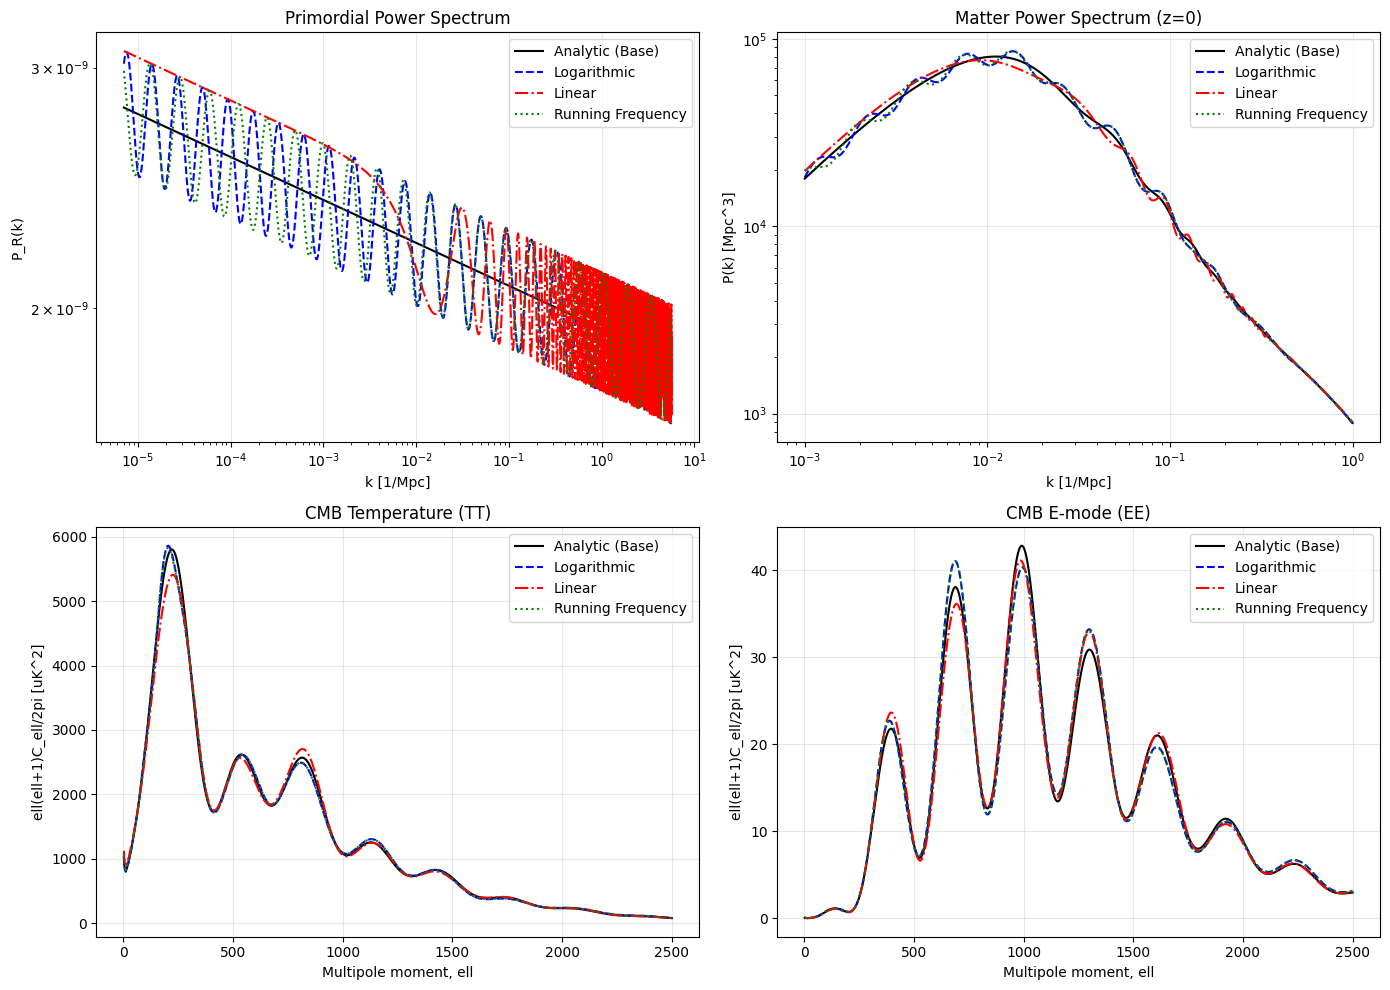

In [3]:
# Group the models for easy looping
models = [
    (cosmo_0, 'Analytic (Base)', 'black', '-'),
    (cosmo_1, 'Logarithmic', 'blue', '--'),
    (cosmo_2, 'Linear', 'red', '-.'),
    (cosmo_3, 'Running Frequency', 'green', ':')
]

# Set up the 2x2 plot
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# 1. Primordial Power Spectrum (Top Left)
ax[0, 0].set_title('Primordial Power Spectrum')
ax[0, 0].set_xlabel('k [1/Mpc]')
ax[0, 0].set_ylabel('P_R(k)')

# 2. Matter Power Spectrum Today (Top Right)
ax[0, 1].set_title('Matter Power Spectrum (z=0)')
ax[0, 1].set_xlabel('k [1/Mpc]')
ax[0, 1].set_ylabel('P(k) [Mpc^3]')
# Create a k-array based on your P_k_max limit (up to ~1 1/Mpc)
k_m = np.logspace(-3, 0, 400) 

# 3. CMB Temperature TT (Bottom Left)
ax[1, 0].set_title('CMB Temperature (TT)')
ax[1, 0].set_xlabel('Multipole moment, ell')
ax[1, 0].set_ylabel('ell(ell+1)C_ell/2pi [uK^2]')

# 4. CMB E-mode Polarization EE (Bottom Right)
ax[1, 1].set_title('CMB E-mode (EE)')
ax[1, 1].set_xlabel('Multipole moment, ell')
ax[1, 1].set_ylabel('ell(ell+1)C_ell/2pi [uK^2]')

# Extract data and plot for each model
T_cmb_uK = 2.7255e6 # CMB temp in micro-Kelvin

for cosmo, name, color, line in models:
    
    # --- Primordial Power Spectrum ---
    pps = cosmo.get_primordial()
    k_prim = pps['k [1/Mpc]']
    pk_prim = pps['P_scalar(k)']
    ax[0, 0].loglog(k_prim, pk_prim, label=name, color=color, linestyle=line)
    
    # --- Matter Power Spectrum ---
    # cosmo.pk(k, z) evaluates a single k-value, so we loop over the array
    pk_m = np.array([cosmo.pk(k, 0.0) for k in k_m])
    ax[0, 1].loglog(k_m, pk_m, label=name, color=color, linestyle=line)
    
    # --- CMB Spectra ---
    # Extract lensed Cls up to ell=2500
    cls = cosmo.lensed_cl(2500)
    ell = cls['ell'][2:] # Skip ell=0 and 1
    
    # Convert dimensionless Cls to standard uK^2 format
    factor = ell * (ell + 1) / (2 * np.pi) * T_cmb_uK**2
    cl_tt = cls['tt'][2:] * factor
    cl_ee = cls['ee'][2:] * factor
    
    ax[1, 0].plot(ell, cl_tt, label=name, color=color, linestyle=line)
    ax[1, 1].plot(ell, cl_ee, label=name, color=color, linestyle=line)

# Clean up layout and add legends
for axis in ax.flat:
    axis.legend()
    axis.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig("global_model_comparison_plots.png", bbox_inches='tight', dpi=300)
plt.show()

In [6]:
standard_input = {
        'T_cmb':2.7255, #Temperature of CMB today
        'omega_b':2.255065e-02, #Baryon density today
        'omega_cdm':1.193524e-01, #Cold DM density today
        'H0':6.776953e+01, #Hubble Parameter today
        
        'A_s':2.123257e-09, #Primordial power spectrum amplitude
        'n_s':9.686025e-01, #Primordial spectral index
    
        # output quantities
        'output':'mPk, tCl, pCl, lCl',
        'lensing':'yes',
        'P_k_max_h/Mpc':1.0,
        'non_linear':'halofit', 
        'k_per_decade_primordial': 1000
}

cosmo_0 = Class()
cosmo_0.set(standard_input)

cosmo_1 = Class()
cosmo_1.set(standard_input)

# Set your custom parameters
cosmo_0.set({
        'P_k_ini type': 'analytic_Pk',
})
cosmo_0.compute()

cosmo_1.set({
        'P_k_ini type': 'analytic_Pk',
        'modifications': 'local',
        'A_losc': 0.1,
        'k_losc': 0.01,
        'x_losc': 10.0
})
cosmo_1.compute()

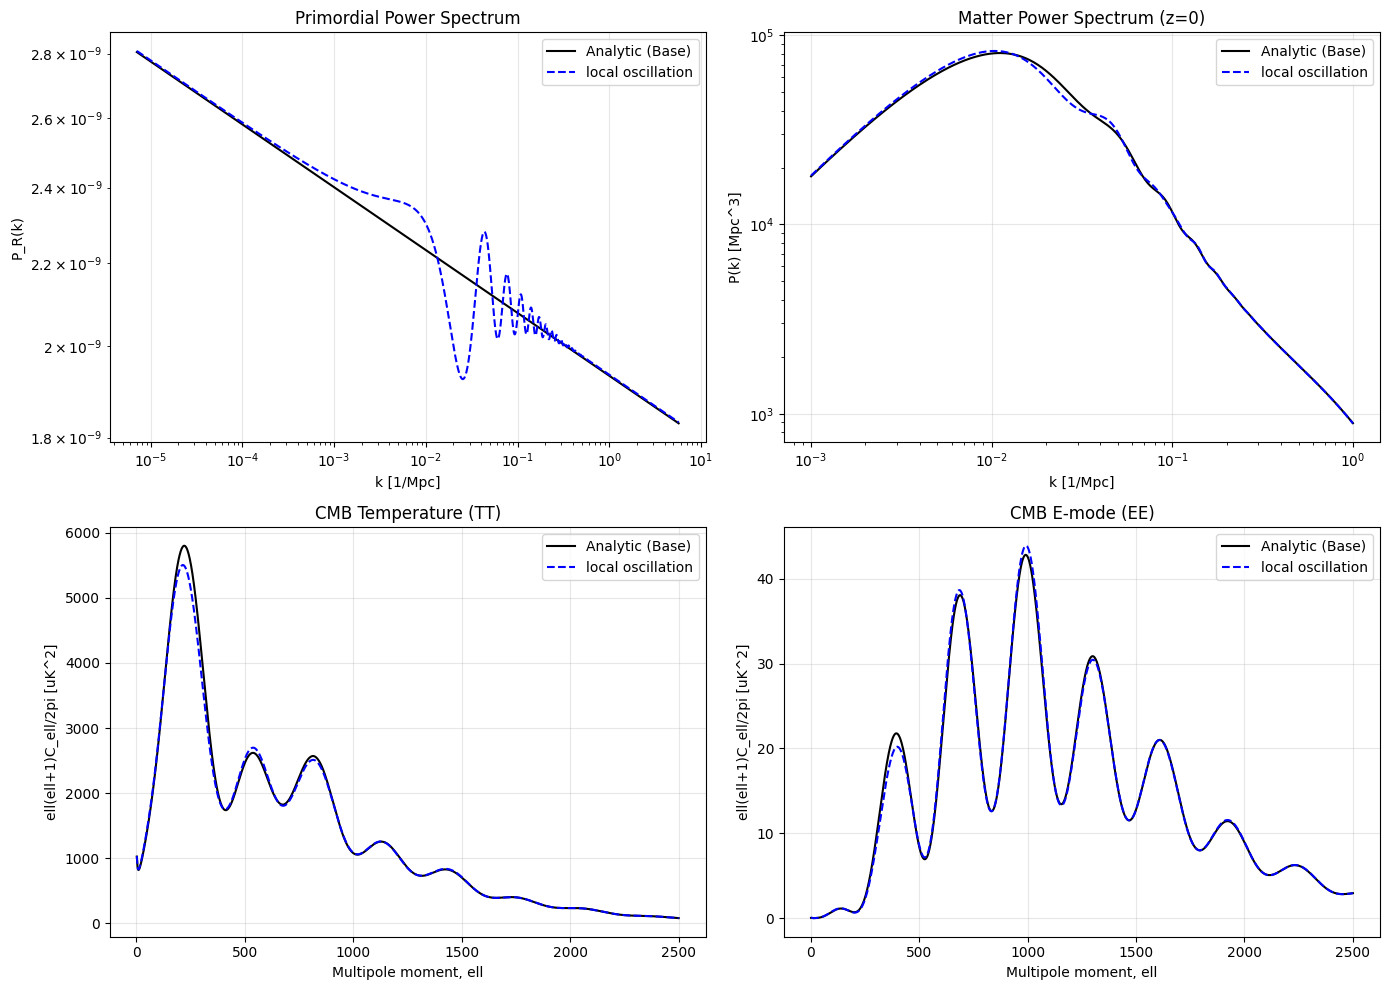

In [7]:
# Group the models for easy looping
models = [
    (cosmo_0, 'Analytic (Base)', 'black', '-'),
    (cosmo_1, 'local oscillation', 'blue', '--'),
]

# Set up the 2x2 plot
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# 1. Primordial Power Spectrum (Top Left)
ax[0, 0].set_title('Primordial Power Spectrum')
ax[0, 0].set_xlabel('k [1/Mpc]')
ax[0, 0].set_ylabel('P_R(k)')

# 2. Matter Power Spectrum Today (Top Right)
ax[0, 1].set_title('Matter Power Spectrum (z=0)')
ax[0, 1].set_xlabel('k [1/Mpc]')
ax[0, 1].set_ylabel('P(k) [Mpc^3]')
# Create a k-array based on your P_k_max limit (up to ~1 1/Mpc)
k_m = np.logspace(-3, 0, 400) 

# 3. CMB Temperature TT (Bottom Left)
ax[1, 0].set_title('CMB Temperature (TT)')
ax[1, 0].set_xlabel('Multipole moment, ell')
ax[1, 0].set_ylabel('ell(ell+1)C_ell/2pi [uK^2]')

# 4. CMB E-mode Polarization EE (Bottom Right)
ax[1, 1].set_title('CMB E-mode (EE)')
ax[1, 1].set_xlabel('Multipole moment, ell')
ax[1, 1].set_ylabel('ell(ell+1)C_ell/2pi [uK^2]')

# Extract data and plot for each model
T_cmb_uK = 2.7255e6 # CMB temp in micro-Kelvin

for cosmo, name, color, line in models:
    
    # --- Primordial Power Spectrum ---
    pps = cosmo.get_primordial()
    k_prim = pps['k [1/Mpc]']
    pk_prim = pps['P_scalar(k)']
    ax[0, 0].loglog(k_prim, pk_prim, label=name, color=color, linestyle=line)
    
    # --- Matter Power Spectrum ---
    # cosmo.pk(k, z) evaluates a single k-value, so we loop over the array
    pk_m = np.array([cosmo.pk(k, 0.0) for k in k_m])
    ax[0, 1].loglog(k_m, pk_m, label=name, color=color, linestyle=line)
    
    # --- CMB Spectra ---
    # Extract lensed Cls up to ell=2500
    cls = cosmo.lensed_cl(2500)
    ell = cls['ell'][2:] # Skip ell=0 and 1
    
    # Convert dimensionless Cls to standard uK^2 format
    factor = ell * (ell + 1) / (2 * np.pi) * T_cmb_uK**2
    cl_tt = cls['tt'][2:] * factor
    cl_ee = cls['ee'][2:] * factor
    
    ax[1, 0].plot(ell, cl_tt, label=name, color=color, linestyle=line)
    ax[1, 1].plot(ell, cl_ee, label=name, color=color, linestyle=line)

# Clean up layout and add legends
for axis in ax.flat:
    axis.legend()
    axis.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig("local_model_comparison_plots.png", bbox_inches='tight', dpi=300)
plt.show()

### Log Model: Parameter Variation

Computing Row 1: Varying A_X...
Computing Row 2: Varying omega_X...
Computing Row 3: Varying phi_X...
Computations complete! Plotting...


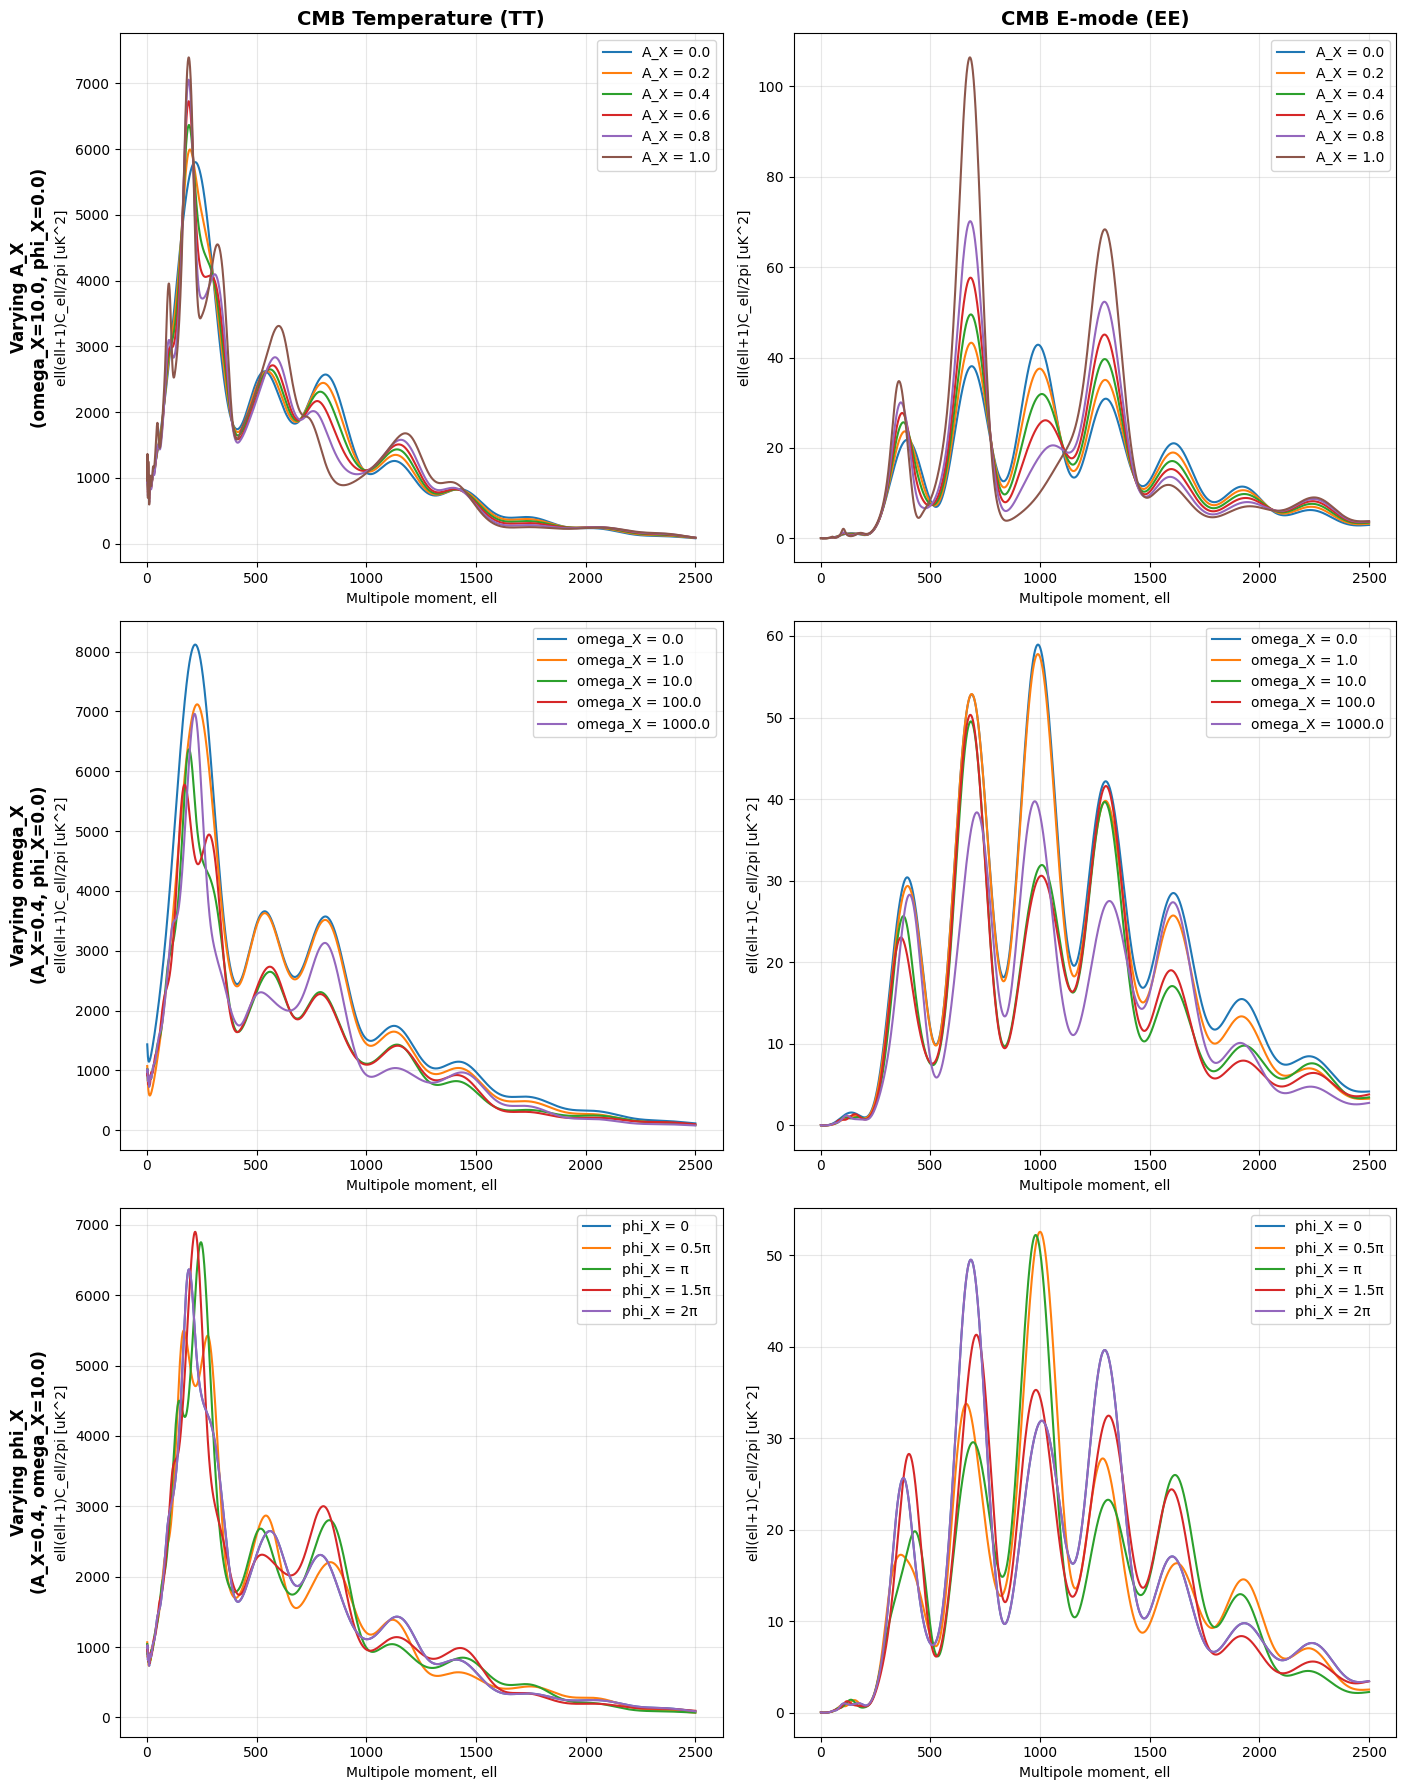

In [24]:
# Your standard baseline parameters
standard_input = {
    'T_cmb': 2.7255, 
    'omega_b': 2.255065e-02, 
    'omega_cdm': 1.193524e-01, 
    'H0': 6.776953e+01, 
    'A_s': 2.123257e-09, 
    'n_s': 9.686025e-01, 
    'output': 'tCl, pCl, lCl', # Just need Cls for this plot to save a bit of time
    'lensing': 'yes',
    'non_linear': 'halofit', 
}

# The parameter ranges you requested
A_X_vals = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
omega_X_vals = [0.0, 1.0, 10.0, 100.0, 1000.0]
phi_X_vals = [0.0, 0.5 * np.pi, np.pi, 1.5 * np.pi, 2.0 * np.pi]
phi_labels = ['0', '0.5π', 'π', '1.5π', '2π']

# Fixed values to use when a parameter isn't the one being varied
fixed_A = 0.4
fixed_omega = 10.0
fixed_phi = 0.0

T_cmb_uK = 2.7255e6 # Conversion factor

# Helper function to run CLASS cleanly inside a loop
def compute_cmb_spectra(A, omega, phi):
    cosmo = Class()
    cosmo.set(standard_input)
    cosmo.set({
        'P_k_ini type': 'modified_Pk',
        'osc_model_type': 'logarithmic',
        'A_X': A,
        'omega_X': omega,
        'phi_X': phi
    })
    cosmo.compute()
    cls = cosmo.lensed_cl(2500)
    cosmo.empty() # Crucial: frees C memory so we don't crash the notebook!
    
    ell = cls['ell'][2:]
    factor = ell * (ell + 1) / (2 * np.pi) * T_cmb_uK**2
    cl_tt = cls['tt'][2:] * factor
    cl_ee = cls['ee'][2:] * factor
    
    return ell, cl_tt, cl_ee

# Set up the 3x2 grid
fig, ax = plt.subplots(3, 2, figsize=(14, 18))

# Column Titles
ax[0, 0].set_title('CMB Temperature (TT)', fontsize=14, weight='bold')
ax[0, 1].set_title('CMB E-mode (EE)', fontsize=14, weight='bold')

print("Computing Row 1: Varying A_X...")
for A in A_X_vals:
    ell, tt, ee = compute_cmb_spectra(A, fixed_omega, fixed_phi)
    label = f'A_X = {A}'
    ax[0, 0].plot(ell, tt, label=label)
    ax[0, 1].plot(ell, ee, label=label)

print("Computing Row 2: Varying omega_X...")
for omega in omega_X_vals:
    ell, tt, ee = compute_cmb_spectra(fixed_A, omega, fixed_phi)
    label = f'omega_X = {omega}'
    ax[1, 0].plot(ell, tt, label=label)
    ax[1, 1].plot(ell, ee, label=label)

print("Computing Row 3: Varying phi_X...")
for i, phi in enumerate(phi_X_vals):
    ell, tt, ee = compute_cmb_spectra(fixed_A, fixed_omega, phi)
    label = f'phi_X = {phi_labels[i]}'
    ax[2, 0].plot(ell, tt, label=label)
    ax[2, 1].plot(ell, ee, label=label)

# Formatting loops
row_labels = [
    f'Varying A_X\n(omega_X={fixed_omega}, phi_X={fixed_phi})', 
    f'Varying omega_X\n(A_X={fixed_A}, phi_X={fixed_phi})', 
    f'Varying phi_X\n(A_X={fixed_A}, omega_X={fixed_omega})'
]

for i in range(3):
    for j in range(2):
        ax[i, j].set_xlabel('Multipole moment, ell')
        ax[i, j].set_ylabel('ell(ell+1)C_ell/2pi [uK^2]')
        ax[i, j].legend()
        ax[i, j].grid(True, alpha=0.3)
    
    # Add a text label to the y-axis to indicate which parameter is varying
    ax[i, 0].annotate(row_labels[i], xy=(-0.15, 0.5), xycoords='axes fraction', 
                      va='center', ha='center', rotation=90, fontsize=12, weight='bold')

plt.tight_layout()
print("Computations complete! Plotting...")
plt.savefig("log_model_par_variations.png", bbox_inches='tight', dpi=300)
plt.show()

### Lin Model: Parameter Variation

Computing Row 1: Varying A_X...
Computing Row 2: Varying omega_X...
Computing Row 3: Varying phi_X...
Computations complete! Plotting...


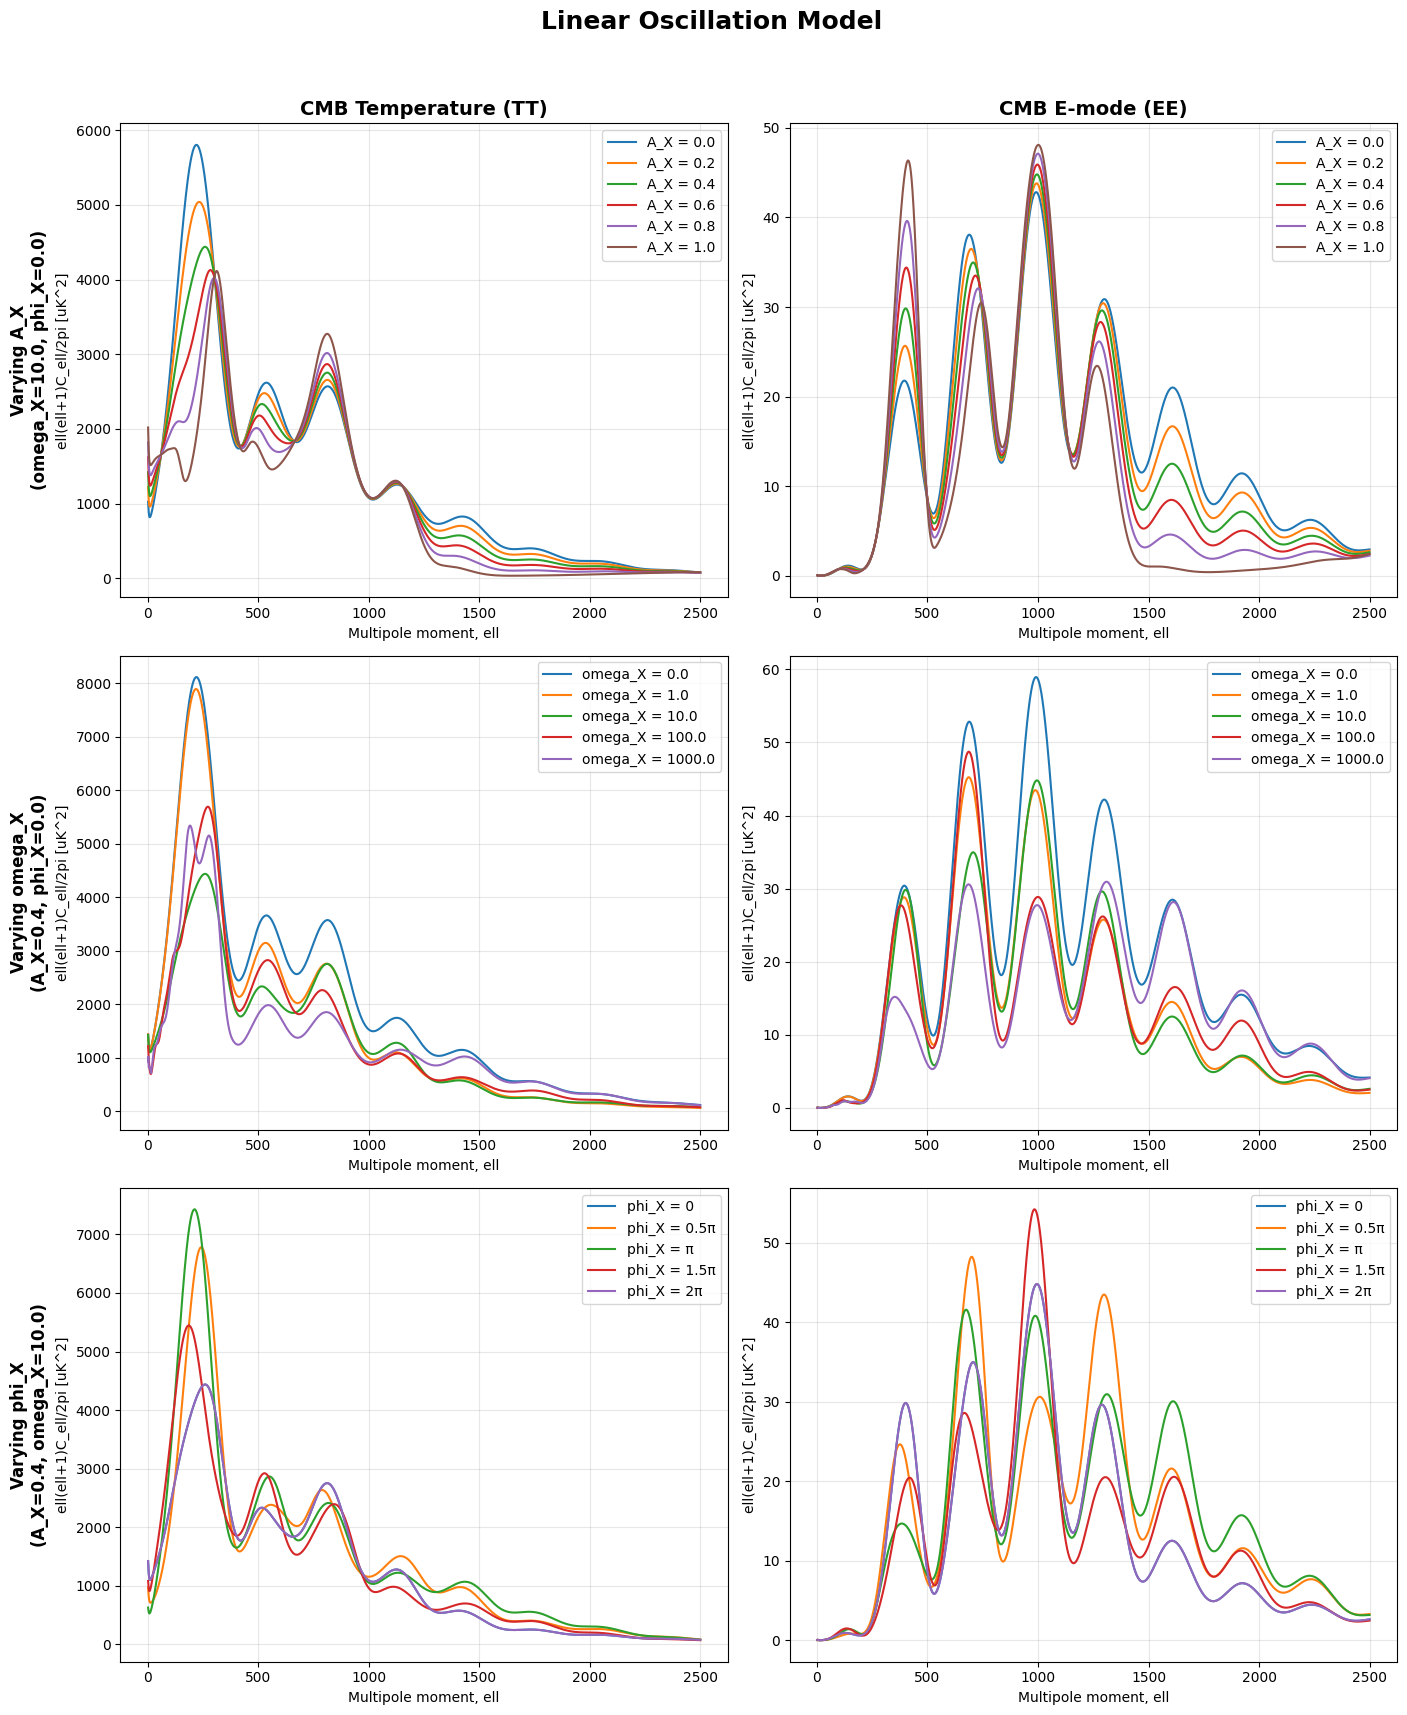

In [26]:
# Your standard baseline parameters
standard_input = {
    'T_cmb': 2.7255, 
    'omega_b': 2.255065e-02, 
    'omega_cdm': 1.193524e-01, 
    'H0': 6.776953e+01, 
    'A_s': 2.123257e-09, 
    'n_s': 9.686025e-01, 
    'output': 'tCl, pCl, lCl', 
    'lensing': 'yes',
    'non_linear': 'halofit', 
}

# The parameter ranges
A_X_vals = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
omega_X_vals = [0.0, 1.0, 10.0, 100.0, 1000.0]
phi_X_vals = [0.0, 0.5 * np.pi, np.pi, 1.5 * np.pi, 2.0 * np.pi]
phi_labels = ['0', '0.5π', 'π', '1.5π', '2π']

# Fixed values to use when a parameter isn't the one being varied
fixed_A = 0.4
fixed_omega = 10.0
fixed_phi = 0.0

T_cmb_uK = 2.7255e6 # Conversion factor

# Helper function to run CLASS cleanly inside a loop (Modified for Linear)
def compute_cmb_spectra_linear(A, omega, phi):
    cosmo = Class()
    cosmo.set(standard_input)
    cosmo.set({
        'P_k_ini type': 'modified_Pk',
        'osc_model_type': 'linear',  # <--- Changed to linear here!
        'A_X': A,
        'omega_X': omega,
        'phi_X': phi
    })
    cosmo.compute()
    cls = cosmo.lensed_cl(2500)
    cosmo.empty() # Crucial: frees C memory
    
    ell = cls['ell'][2:]
    factor = ell * (ell + 1) / (2 * np.pi) * T_cmb_uK**2
    cl_tt = cls['tt'][2:] * factor
    cl_ee = cls['ee'][2:] * factor
    
    return ell, cl_tt, cl_ee

# Set up the 3x2 grid
fig, ax = plt.subplots(3, 2, figsize=(14, 18))
fig.suptitle('Linear Oscillation Model', fontsize=18, weight='bold', y=0.98)

# Column Titles
ax[0, 0].set_title('CMB Temperature (TT)', fontsize=14, weight='bold')
ax[0, 1].set_title('CMB E-mode (EE)', fontsize=14, weight='bold')

print("Computing Row 1: Varying A_X...")
for A in A_X_vals:
    ell, tt, ee = compute_cmb_spectra_linear(A, fixed_omega, fixed_phi)
    label = f'A_X = {A}'
    ax[0, 0].plot(ell, tt, label=label)
    ax[0, 1].plot(ell, ee, label=label)

print("Computing Row 2: Varying omega_X...")
for omega in omega_X_vals:
    ell, tt, ee = compute_cmb_spectra_linear(fixed_A, omega, fixed_phi)
    label = f'omega_X = {omega}'
    ax[1, 0].plot(ell, tt, label=label)
    ax[1, 1].plot(ell, ee, label=label)

print("Computing Row 3: Varying phi_X...")
for i, phi in enumerate(phi_X_vals):
    ell, tt, ee = compute_cmb_spectra_linear(fixed_A, fixed_omega, phi)
    label = f'phi_X = {phi_labels[i]}'
    ax[2, 0].plot(ell, tt, label=label)
    ax[2, 1].plot(ell, ee, label=label)

# Formatting loops
row_labels = [
    f'Varying A_X\n(omega_X={fixed_omega}, phi_X={fixed_phi})', 
    f'Varying omega_X\n(A_X={fixed_A}, phi_X={fixed_phi})', 
    f'Varying phi_X\n(A_X={fixed_A}, omega_X={fixed_omega})'
]

for i in range(3):
    for j in range(2):
        ax[i, j].set_xlabel('Multipole moment, ell')
        ax[i, j].set_ylabel('ell(ell+1)C_ell/2pi [uK^2]')
        ax[i, j].legend()
        ax[i, j].grid(True, alpha=0.3)
    
    # Add a text label to the y-axis to indicate which parameter is varying
    ax[i, 0].annotate(row_labels[i], xy=(-0.15, 0.5), xycoords='axes fraction', 
                      va='center', ha='center', rotation=90, fontsize=12, weight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to fit the suptitle
print("Computations complete! Plotting...")
plt.savefig("lin_model_par_variations.png", bbox_inches='tight', dpi=300)
plt.show()

### rf Model: Running Frequency Variation

Computing Running Frequency Spectra: Varying alpha_rf...
Computations complete! Plotting...


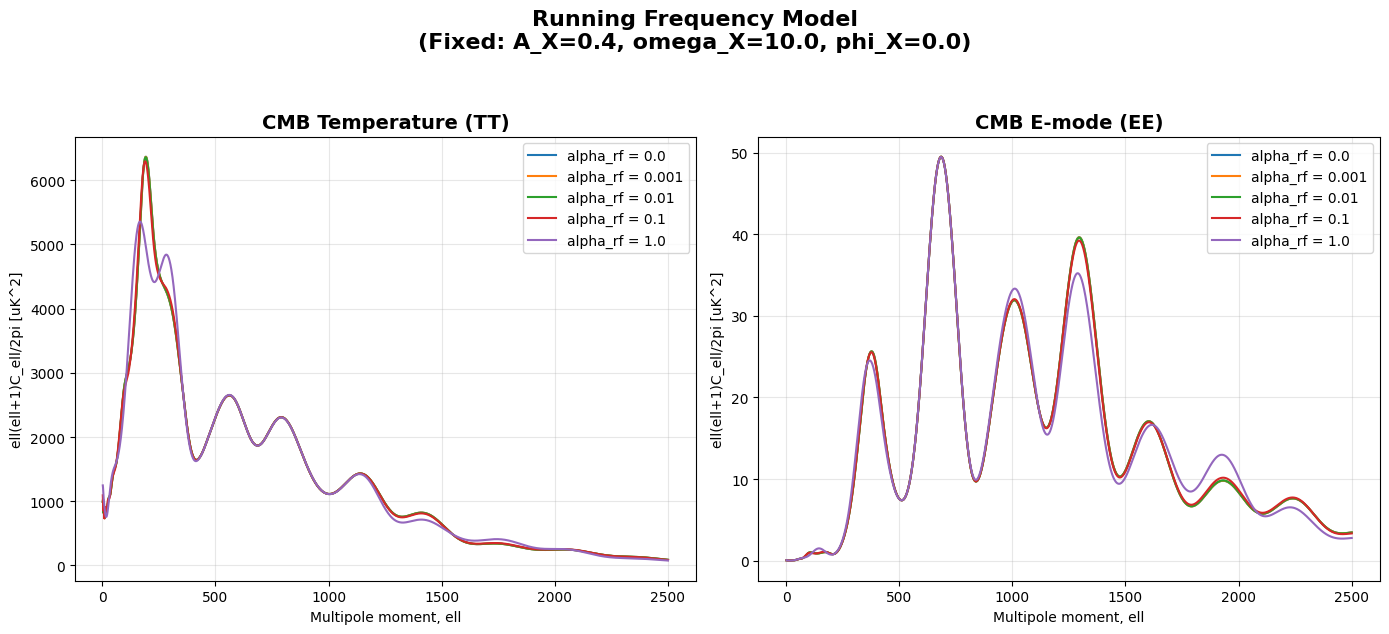

In [27]:
# Your standard baseline parameters
standard_input = {
    'T_cmb': 2.7255, 
    'omega_b': 2.255065e-02, 
    'omega_cdm': 1.193524e-01, 
    'H0': 6.776953e+01, 
    'A_s': 2.123257e-09, 
    'n_s': 9.686025e-01, 
    'output': 'tCl, pCl, lCl', 
    'lensing': 'yes',
    'non_linear': 'halofit', 
}

# The parameter ranges for alpha_rf
alpha_rf_vals = [0.0, 0.001, 0.01, 0.1, 1.0]

# Fixed values for the base oscillation
fixed_A = 0.4
fixed_omega = 10.0
fixed_phi = 0.0

T_cmb_uK = 2.7255e6 # Conversion factor

# Helper function to run CLASS cleanly inside a loop (Modified for Running Frequency)
def compute_cmb_spectra_rf(alpha):
    cosmo = Class()
    cosmo.set(standard_input)
    cosmo.set({
        'P_k_ini type': 'modified_Pk',
        'osc_model_type': 'running_frequency',  # <--- Changed to running_frequency
        'A_X': fixed_A,
        'omega_X': fixed_omega,
        'phi_X': fixed_phi,
        'alpha_rf': alpha  # <--- Passing the varying alpha parameter
    })
    cosmo.compute()
    cls = cosmo.lensed_cl(2500)
    cosmo.empty() # Crucial: frees C memory
    
    ell = cls['ell'][2:]
    factor = ell * (ell + 1) / (2 * np.pi) * T_cmb_uK**2
    cl_tt = cls['tt'][2:] * factor
    cl_ee = cls['ee'][2:] * factor
    
    return ell, cl_tt, cl_ee

# Set up the 1x2 grid
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Running Frequency Model\n(Fixed: A_X={fixed_A}, omega_X={fixed_omega}, phi_X={fixed_phi})', 
             fontsize=16, weight='bold', y=1.05)

# Column Titles
ax[0].set_title('CMB Temperature (TT)', fontsize=14, weight='bold')
ax[1].set_title('CMB E-mode (EE)', fontsize=14, weight='bold')

print("Computing Running Frequency Spectra: Varying alpha_rf...")
for alpha in alpha_rf_vals:
    ell, tt, ee = compute_cmb_spectra_rf(alpha)
    label = f'alpha_rf = {alpha}'
    ax[0].plot(ell, tt, label=label)
    ax[1].plot(ell, ee, label=label)

# Formatting loops
for j in range(2):
    ax[j].set_xlabel('Multipole moment, ell')
    ax[j].set_ylabel('ell(ell+1)C_ell/2pi [uK^2]')
    ax[j].legend()
    ax[j].grid(True, alpha=0.3)

plt.tight_layout()
print("Computations complete! Plotting...")
plt.savefig("rf_model_par_variations.png", bbox_inches='tight', dpi=300)
plt.show()